In [1]:
# considering variance > 0.25 as rules to classify gene categories
suppressMessages(suppressWarnings({
    library(dplyr)
    library(ggplot2)
    library(tidyr)
    library(ggvenn)
    library(ggpubr)
}))

In [2]:
# update LMM results using > 0.25 as threshold
get_res <- function(exp, type){
    for (species in c('Hsap', 'Mmus', 'Pvit', 'Pmar')){
        results <- read.delim(paste0(species,'.', type ,'.LMM_variance_decomp.cell_vs_location.txt'))
        results$Category <- "None"
        results[results$location > 0.25 & results$celltype < 0.25, "Category"] <- "High across location"
        results[results$location < 0.25 & results$celltype > 0.25, "Category"] <- "High across cell type family"
        results[results$location > 0.25 & results$celltype > 0.25, "Category"] <- "Both to location and cell type"
        write.table(results, paste0(species,'.', type ,'.LMM_variance_decomp.cell_vs_location.v2.txt'), quote = F, sep = '\t', row.names = F, col.names = T)
        
        p <- ggplot(results, aes(x = celltype, y = location, color = Category)) +
            geom_point(alpha = 0.6, size = 2) +
            scale_color_manual(values = c("High across location" = "#A4CB9E",
                                    "High across cell type family" = "#E17327",
                                    "Both to location and cell type" = "#6D65A3",
                                    "None" = "#A3A5A6"
                                    )) +
            labs(x = "Fraction of variance across cell type family", y = "Fraction of variance across location", color = "Category") +
            theme_minimal() + theme( legend.position = "top", text = element_text(size = 12)) + coord_fixed(ratio = 1)
        ggsave(paste0("figures/", species,'.',type,".LMM_variance_decomp.cell_vs_location.pdf"), p, width = 6, height = 6)    
    }
}

get_res(exp_AST_GABA, 'AST_GABA')
get_res(exp_AST_Glut, 'AST_Glut')

In [3]:
# load background genes (protein-coding genes) in our datasets
Hsap_bg <- read.table("/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/04.ohno_para_significance/4.GO_enrichment/Hsap_bg")$V1
Mmus_bg <- read.table("/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/04.ohno_para_significance/4.GO_enrichment/Mmus_bg")$V1
Pvit_bg <- read.table("/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/04.ohno_para_significance/4.GO_enrichment/Pvit_bg")$V1
Pmar_bg <- read.table("/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/04.ohno_para_significance/4.GO_enrichment/Pmar_bg")$V1

In [4]:
# Function to calculate overlap and p-value
calc_pvalue <- function(set1, set2, universe_size) {
  overlap <- length(intersect(set1, set2))
  matrix_vals <- matrix(c(overlap, length(set1) - overlap, length(set2) - overlap, universe_size - length(set1) - length(set2) + overlap), 
                        nrow = 2)
    if(fisher.test(matrix_vals)$estimate <= 1){
        return(1)
    } else {
        fisher.test(matrix_vals)$p.value
    }
}


get_res <- function(species, universe_size){
    x1 = read.delim(paste0(species, '.AST_GABA.LMM_variance_decomp.cell_vs_location.txt'), header = T)
    x2 = read.delim(paste0(species, '.AST_Glut.LMM_variance_decomp.cell_vs_location.txt'), header = T)
    
    gene_sets <- list(
        "AST-Glut Location" = x2[x2$location > 0.25, 1],
        "AST-GABA Location" = x1[x1$location > 0.25, 1],
        "AST-Glut CellType" = x2[x2$celltype > 0.25, 1],
        "AST-GABA CellType" = x1[x1$celltype > 0.25, 1]
    )
    # Calculate p-values matrix
    p_values <- matrix(NA, nrow = 4, ncol = 4)
    rownames(p_values) <- colnames(p_values) <- names(gene_sets)
    for (i in 1:4) {
        for (j in 1:4) {
            p_values[i, j] <- calc_pvalue(gene_sets[[i]], gene_sets[[j]], universe_size)
        }
    }
    
    # Convert to -log10 scale
    log_p_values <- -log10(p_values)

    # Melt for ggplot2
    log_p_values_melt <- reshape2::melt(log_p_values, na.rm = TRUE)
    log_p_values_melt$number <- vapply(1:nrow(log_p_values_melt), FUN = function(row){
        var1 = log_p_values_melt[row, 1]
        var2 = log_p_values_melt[row, 2]
        return(length(intersect(gene_sets[[var1]], gene_sets[[var2]])))
    }, FUN.VALUE = numeric(1))
    
    log_p_values_melt[is.infinite(log_p_values_melt$value), 'value'] = 200 # set a large value to represent -log(0)
    log_p_values_melt[which(log_p_values_melt$Var1 == log_p_values_melt$Var2), 'value'] <- NA
    p <- ggplot(log_p_values_melt, aes(Var1, Var2, fill = value)) + 
        geom_tile(color = "white") + 
        scale_fill_gradient(low = "grey", high = "red", na.value = "white", 
                            name = expression(-log[10](P)), limits = c(0, 10), oob = scales::squish) +
        geom_text(aes(label = number), color = "black") + theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
        labs(x = "", y = "", title = "Gene List Comparison Matrix")
    ggsave(p, filename = paste0('figures/', species, '.comparison_mat.pdf'), width = 6, height = 5)
}

In [5]:
get_res("Hsap", length(Hsap_bg))
get_res("Mmus", length(Mmus_bg))
get_res("Pvit", length(Pvit_bg))
get_res("Pmar", length(Pmar_bg))

In [6]:
# find conserved regionalisation genes
find_location_genes <- function (file){
    AST_n <- read.delim(file, header = T)
    AST_n <- AST_n[AST_n$location > 0.25, 'Gene']
    return(AST_n)
}

regionalisation_genes = list(Hsap_AST_GABA = find_location_genes('Hsap.AST_GABA.LMM_variance_decomp.cell_vs_location.txt'),
                             Hsap_AST_Glut = find_location_genes('Hsap.AST_Glut.LMM_variance_decomp.cell_vs_location.txt'),
                             Mmus_AST_GABA = find_location_genes('Mmus.AST_GABA.LMM_variance_decomp.cell_vs_location.txt'),
                             Mmus_AST_Glut = find_location_genes('Mmus.AST_Glut.LMM_variance_decomp.cell_vs_location.txt'),
                             Pvit_AST_GABA = find_location_genes('Pvit.AST_GABA.LMM_variance_decomp.cell_vs_location.txt'),
                             Pvit_AST_Glut = find_location_genes('Pvit.AST_Glut.LMM_variance_decomp.cell_vs_location.txt'),
                             Pmar_AST_GABA = find_location_genes('Pmar.AST_GABA.LMM_variance_decomp.cell_vs_location.txt'),
                             Pmar_AST_Glut = find_location_genes('Pmar.AST_Glut.LMM_variance_decomp.cell_vs_location.txt'))


In [7]:
# load orthogroups
orthogroups <- read.delim('/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/02.gene_relationships/run4/results/Ortho_pipeline/OrthoFinder/Orthogroups/Orthogroups.tsv')
# *** at least one copy for at least one species
orthogroups <- orthogroups %>% select(c('Orthogroup', 'Pmar', 'Pvit', 'Mmus', 'Hsap'))  %>% 
    filter(Pmar != '' | Pvit != ''  | Mmus != '' | Hsap != '')
# having at least one copy for each species scoped, for below GO background 
orthogroups2 <- orthogroups %>% select(c('Orthogroup', 'Pmar', 'Pvit', 'Mmus', 'Hsap'))  %>% 
    filter(Pmar != '' & Pvit != ''  & Mmus != '' & Hsap != '')

In [8]:
# find shared orthogroups for AST-GABA regionalisation across vertebrates
Hsap_AST_GABA_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Hsap, sep = ", ") %>% 
    filter(Hsap %in% regionalisation_genes[['Hsap_AST_GABA']]) %>% distinct() %>% select(Orthogroup)))
Mmus_AST_GABA_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Mmus, sep = ", ") %>% 
    filter(Mmus %in% regionalisation_genes[['Mmus_AST_GABA']]) %>% distinct() %>% select(Orthogroup)))
Pvit_AST_GABA_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Pvit, sep = ", ") %>% 
    filter(Pvit %in% regionalisation_genes[['Pvit_AST_GABA']]) %>% distinct() %>% select(Orthogroup)))
Pmar_AST_GABA_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Pmar, sep = ", ") %>% 
    filter(Pmar %in% regionalisation_genes[['Pmar_AST_GABA']]) %>% distinct() %>% select(Orthogroup)))

# Amniote conserved
Amniote_AST_GABA_region_orthogroups <- intersect(intersect(Hsap_AST_GABA_region_orthogroups, Mmus_AST_GABA_region_orthogroups), Pvit_AST_GABA_region_orthogroups)
# Vertebrate conserved
Vertebrate_AST_GABA_region_orthogroups <- intersect(Amniote_AST_GABA_region_orthogroups, Pmar_AST_GABA_region_orthogroups)


In [9]:
# find shared orthogroups for AST-Glut regionalisation across vertebrates
Hsap_AST_Glut_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Hsap, sep = ", ") %>% 
    filter(Hsap %in% regionalisation_genes[['Hsap_AST_Glut']]) %>% distinct() %>% select(Orthogroup)))
Mmus_AST_Glut_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Mmus, sep = ", ") %>% 
    filter(Mmus %in% regionalisation_genes[['Mmus_AST_Glut']]) %>% distinct() %>% select(Orthogroup)))
Pvit_AST_Glut_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Pvit, sep = ", ") %>% 
    filter(Pvit %in% regionalisation_genes[['Pvit_AST_Glut']]) %>% distinct() %>% select(Orthogroup)))
Pmar_AST_Glut_region_orthogroups <- unique(unlist(orthogroups %>% separate_rows(Pmar, sep = ", ") %>% 
    filter(Pmar %in% regionalisation_genes[['Pmar_AST_Glut']]) %>% distinct() %>% select(Orthogroup)))

# Amniote conserved
Amniote_AST_Glut_region_orthogroups <- intersect(intersect(Hsap_AST_Glut_region_orthogroups, Mmus_AST_Glut_region_orthogroups), Pvit_AST_Glut_region_orthogroups)
# Vertebrate conserved
Vertebrate_AST_Glut_region_orthogroups <- intersect(Amniote_AST_Glut_region_orthogroups, Pmar_AST_Glut_region_orthogroups)

In [10]:
# regionalisation genes in the vertebrate-conserved AST-Glut/AST-GABA regionalisation orthogroups
Hsap_genes_in_region_orthogroups = unlist(orthogroups %>% filter(Orthogroup %in% c(Vertebrate_AST_Glut_region_orthogroups, Vertebrate_AST_GABA_region_orthogroups)) %>% separate_rows(Hsap, sep = ", ") %>%  
    filter(Hsap %in% c(regionalisation_genes[['Hsap_AST_Glut']], regionalisation_genes[['Hsap_AST_GABA']])) %>% distinct() %>% select(Hsap))
Mmus_genes_in_region_orthogroups = unlist(orthogroups %>% filter(Orthogroup %in% c(Vertebrate_AST_Glut_region_orthogroups, Vertebrate_AST_GABA_region_orthogroups)) %>% separate_rows(Mmus, sep = ", ") %>%  
    filter(Mmus %in% c(regionalisation_genes[['Mmus_AST_Glut']], regionalisation_genes[['Mmus_AST_GABA']])) %>% distinct() %>% select(Mmus))
Pvit_genes_in_region_orthogroups = unlist(orthogroups %>% filter(Orthogroup %in% c(Vertebrate_AST_Glut_region_orthogroups, Vertebrate_AST_GABA_region_orthogroups)) %>% separate_rows(Pvit, sep = ", ") %>%  
    filter(Pvit %in% c(regionalisation_genes[['Pvit_AST_Glut']], regionalisation_genes[['Pvit_AST_GABA']])) %>% distinct() %>% select(Pvit))
Pmar_genes_in_region_orthogroups = unlist(orthogroups %>% filter(Orthogroup %in% c(Vertebrate_AST_Glut_region_orthogroups, Vertebrate_AST_GABA_region_orthogroups)) %>% separate_rows(Pmar, sep = ", ") %>%  
    filter(Pmar %in% c(regionalisation_genes[['Pmar_AST_Glut']], regionalisation_genes[['Pmar_AST_GABA']])) %>% distinct() %>% select(Pmar))

In [11]:
# check and plot overalp across species by Fisher's exact test, comparing at orthogroup level
get_res2 <- function(type){
    species <- c('Hsap', 'Mmus', 'Pvit', 'Pmar')
    # Calculate p-values matrix
    p_values <- matrix(NA, nrow = 4, ncol = 4)
    intersect_numbers <- matrix(NA, nrow = 4, ncol = 4)
    rownames(p_values) <- colnames(p_values) <- species
    rownames(intersect_numbers) <- colnames(intersect_numbers) <- species
    for (i in species) {
        for (j in species) {
            if (i != j){
                set1 = get(paste0(i,'_AST_', type, '_region_orthogroups'))
                set2 = get(paste0(j,'_AST_', type, '_region_orthogroups'))
                
                p_values[i, j] <- calc_pvalue(set1, set2, nrow(orthogroups))
                intersect_numbers[i,j] <- length(intersect(set1, set2))
            } else {
                p_values[i, j] <- 1
                set1 = get(paste0(i,'_AST_', type, '_region_orthogroups'))
                intersect_numbers[i,j] <- length(set1)
            }
        }
    }
    
    # Convert to -log10 scale
    log_p_values <- -log10(p_values)

    # Melt for ggplot2
    log_p_values_melt <- reshape2::melt(log_p_values, na.rm = TRUE)
    log_p_values_melt$number <- vapply(1:nrow(log_p_values_melt), FUN = function(row){
        var1 = log_p_values_melt[row, 1]
        var2 = log_p_values_melt[row, 2]
        return(intersect_numbers[var1, var2])
    }, FUN.VALUE = numeric(1))
    
    log_p_values_melt[is.infinite(log_p_values_melt$value), 'value'] = 200 # set a large value to represent -log(0)
    log_p_values_melt[which(log_p_values_melt$Var1 == log_p_values_melt$Var2), 'value'] <- NA
    p <- ggplot(log_p_values_melt, aes(Var1, Var2, fill = value)) + 
        geom_tile(color = "white") + 
        scale_fill_gradient(low = "grey", high = "red", na.value = "white", 
                            name = expression(-log[10](P)), limits = c(0, 10), oob = scales::squish) +
        geom_text(aes(label = number), color = "black") + theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
        labs(x = "", y = "", title = "Orthogroup Comparison Matrix")
    ggsave(p, filename = paste0('figures/Vertebrate.AST_', type, '.comparison_mat_across_species_orthogroup_level.pdf'), width = 6, height = 5)
    
}

In [12]:
get_res2('GABA')
get_res2('Glut')

In [13]:
# GO enrichment plot 
suppressPackageStartupMessages({
    library(org.Hs.eg.db)
    library(org.Mm.eg.db)
    library(org.Pvitticeps.eg.db)
    library(org.Pmarinus.eg.db)
    library(clusterProfiler)
    library(enrichplot)
    library(ggplot2)
})
options(enrichplot.colours = c("red","blue"))

Warning message:
“package ‘Biobase’ was built under R version 4.3.3”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”


In [14]:
Hsap_bg2 <- Hsap_bg[Hsap_bg %in% unlist(orthogroups2 %>% separate_rows(Hsap, sep = ", ") %>% select(Hsap))]
Hsap_ego2 <- enrichGO(gene         = Hsap_genes_in_region_orthogroups,
                 OrgDb         = org.Hs.eg.db,
                 keyType = "ENSEMBL",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Hsap_bg2,
                 ont  = "BP")

In [25]:
Mmus_bg2 <- Mmus_bg[Mmus_bg %in% unlist(orthogroups2 %>% separate_rows(Mmus, sep = ", ") %>% select(Mmus))]
Mmus_ego2 <- enrichGO(gene         = Mmus_genes_in_region_orthogroups,
                 OrgDb         = org.Mm.eg.db,
                 keyType = "SYMBOL",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Mmus_bg2,
                 ont  = "BP")

In [16]:
Pvit_bg2 <- Pvit_bg[Pvit_bg %in% unlist(orthogroups2 %>% separate_rows(Pvit, sep = ", ") %>% select(Pvit))]
Pvit_ego2 <- enrichGO(gene         = Pvit_genes_in_region_orthogroups,
                 OrgDb         = org.Pvitticeps.eg.db,
                 keyType = "GID",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Pvit_bg2,
                 ont  = "BP")

In [17]:
Pmar_bg2 <- Pmar_bg[Pmar_bg %in% unlist(orthogroups2 %>% separate_rows(Pmar, sep = ", ") %>% select(Pmar))]
Pmar_ego2 <- enrichGO(gene         = Pmar_genes_in_region_orthogroups,
                 OrgDb         = org.Pmarinus.eg.db,
                 keyType = "GID",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Pmar_bg2,
                 ont  = "BP")

In [18]:
# plot selected terms for extended data figures
#selected <- c('regionalization', 'forebrain development', 'embryonic organ development', 'forebrain regionalization', 'telencephalon development',
#              'dorsal/ventral pattern formation', 'proximal/distal pattern formation', 
#              'pattern specification process', 'neuron fate determination', 'anterior/posterior pattern specification',
#             'embryonic organ development', 'axon development', 'diencephalon development', 'renal tubule development')
#fig <- dotplot(Hsap_ego2, showCategory = selected)
#ggsave(filename = "figures/Hsap.conserved_regionalisation_genes.selectedGO.pdf", fig, width = 5, height = 6)
#
#selected <- c('pattern specification process', 'anterior/posterior pattern specification','forebrain regionalization', 'embryonic organ development', 'cell fate determination',
#             'regulation of nervous system development','regulation of neuron differentiation', 'hindbrain development',
#             'midbrain development', 'dorsal/ventral pattern formation', 'proximal/distal pattern formation',
#             'embryonic brain development', 'sensory system development', 'visual system development')
#fig <- dotplot(Mmus_ego2, showCategory = selected)
#ggsave(filename = "figures/Mmus.conserved_regionalisation_genes.selectedGO.pdf", fig, width = 5, height = 6)
#
#selected <- c('neural crest cell development', 'forebrain development', 'hindbrain development', 'telencephalon development',
#              'neuron fate commitment','forebrain regionalization','pattern specification process', 'regionalization',
#             'regulation of nervous system development', 'cell fate determination','embryonic brain development', 'dorsal/ventral pattern formation', 
#              'anterior/posterior pattern specification','proximal/distal pattern formation', 'stem cell development')
#fig <- dotplot(Pvit_ego2, showCategory = selected)
#ggsave(filename = "figures/Pvit.conserved_regionalisation_genes.selectedGO.pdf", fig, width = 5, height = 6)
#
#selected <- c('regionalization', 'pattern specification process', 'anterior/posterior pattern specification', 'dorsal/ventral pattern formation',
#              'forebrain regionalization', 'midbrain-hindbrain boundary development', 'proximal/distal pattern formation', 'embryonic organ development',
#              'cell fate commitment', 'midbrain development', 'forebrain development', 'diencephalon development', 'axonogenesis', 'telencephalon development')
#fig <- dotplot(Pmar_ego2, showCategory = selected)
#ggsave(filename = "figures/Pmar.conserved_regionalisation_genes.selectedGO.pdf", fig, width = 5, height = 6)

In [35]:
# select some genes with regionalization/development function for Fig. 4d
# Mmus_ego2@result

In [43]:
# Please ignore this:
#Hsap_genes_in_regionalisation <- intersect(regionalisation_genes[['Hsap_AST_Glut']], regionalisation_genes[['Hsap_AST_GABA']])
#Mmus_genes_in_regionalisation <- intersect(regionalisation_genes[['Mmus_AST_Glut']], regionalisation_genes[['Mmus_AST_GABA']])
#Pvit_genes_in_regionalisation <- intersect(regionalisation_genes[['Pvit_AST_Glut']], regionalisation_genes[['Pvit_AST_GABA']])
#Pmar_genes_in_regionalisation <- intersect(regionalisation_genes[['Pmar_AST_Glut']], regionalisation_genes[['Pmar_AST_GABA']])

Hsap_genes_in_regionalisation <- unique(c(regionalisation_genes[['Hsap_AST_Glut']], regionalisation_genes[['Hsap_AST_GABA']]))
Mmus_genes_in_regionalisation <- unique(c(regionalisation_genes[['Mmus_AST_Glut']], regionalisation_genes[['Mmus_AST_GABA']]))
Pvit_genes_in_regionalisation <- unique(c(regionalisation_genes[['Pvit_AST_Glut']], regionalisation_genes[['Pvit_AST_GABA']]))
Pmar_genes_in_regionalisation <- unique(c(regionalisation_genes[['Pmar_AST_Glut']], regionalisation_genes[['Pmar_AST_GABA']]))

Hsap_ego2 <- enrichGO(gene         = Hsap_genes_in_regionalisation,
                 OrgDb         = org.Hs.eg.db,
                 keyType = "ENSEMBL",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Hsap_bg2,
                 ont  = "BP")

Mmus_ego2 <- enrichGO(gene         = Mmus_genes_in_regionalisation,
                 OrgDb         = org.Mm.eg.db,
                 keyType = "SYMBOL",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Mmus_bg2,
                 ont  = "BP")

Pvit_ego2 <- enrichGO(gene         = Pvit_genes_in_regionalisation,
                 OrgDb         = org.Pvitticeps.eg.db,
                 keyType = "GID",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Pvit_bg2,
                 ont  = "BP")

Pmar_ego2 <- enrichGO(gene         = Pmar_genes_in_regionalisation,
                 OrgDb         = org.Pmarinus.eg.db,
                 keyType = "GID",
                 pAdjustMethod = "BH",
                 pvalueCutoff = 0.05,
                 universe = Pmar_bg2,
                 ont  = "BP")

In [51]:
#  manually select regional-identity genes in Fig. 4g with perference of developmental function
# manually check functional terms, check which genes contribute to enrichment, and check gene expression
Mmus_ego2@result[grepl('forebrain', Mmus_ego2@result$Description), ]
unique(Reduce(c, lapply(Mmus_ego2@result[grepl('forebrain', Mmus_ego2@result$Description), "geneID"], FUN = function(x){
    strsplit(x, split = '/')[[1]]
})))
Mmus_ego2@result[grepl('dien', Mmus_ego2@result$Description), ]
unique(Reduce(c, lapply(Mmus_ego2@result[grepl('dien', Mmus_ego2@result$Description), "geneID"], FUN = function(x){
    strsplit(x, split = '/')[[1]]
})))
Mmus_ego2@result[grepl('midbrain', Mmus_ego2@result$Description), ]
unique(Reduce(c, lapply(Mmus_ego2@result[grepl('midbrain', Mmus_ego2@result$Description), "geneID"], FUN = function(x){
    strsplit(x, split = '/')[[1]]
})))
# Pax7 showing good pattern but not enriched into terms
Mmus_ego2@result[grepl('hindbrain', Mmus_ego2@result$Description), ]
unique(Reduce(c, lapply(Mmus_ego2@result[grepl('hindbrain', Mmus_ego2@result$Description), "geneID"], FUN = function(x){
    strsplit(x, split = '/')[[1]]
})))


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0021871,GO:0021871,forebrain regionalization,14/4710,26/13183,0.04462772,1,1,Bhlhe22/Emx1/Emx2/Eomes/Fezf2/Fgf8/Lhx1/Lhx2/Tra2b/Fezf1/Gsx2/Nkx2-1/Otx2/Six3,14
GO:0021879,GO:0021879,forebrain neuron differentiation,24/4710,50/13183,0.04970557,1,1,Atg7/Csf1r/Fezf2/Fgf8/Foxg1/Gbx2/Inhba/Lhx5/Ndnf/Plxna3/Prox1/Shank3/Tbr1/Tfap2a/Ubb/Zswim6/Bcl11b/Dclk2/Dlx1/Dlx2/Nkx2-1/Nrp1/Plxna1/Sema3a,24
GO:0021872,GO:0021872,forebrain generation of neurons,27/4710,60/13183,0.08717362,1,1,Atg7/Csf1r/Dct/Fezf2/Fgf8/Foxg1/Gbx2/Inhba/Lef1/Lhx5/Ndnf/Plxna3/Prox1/Shank3/Tbr1/Tfap2a/Ubb/Zswim6/Bcl11b/Dclk2/Dlx1/Dlx2/Nkx2-1/Nr2e1/Nrp1/Plxna1/Sema3a,27
GO:0021884,GO:0021884,forebrain neuron development,12/4710,28/13183,0.27361164,1,1,Atg7/Fgf8/Foxg1/Gbx2/Ndnf/Plxna3/Tfap2a/Ubb/Dclk2/Nrp1/Plxna1/Sema3a,12
GO:0048853,GO:0048853,forebrain morphogenesis,6/4710,15/13183,0.45951961,1,1,Fgf8/Gsx2/Ift88/Otx1/Otx2/Tuba1a,6
GO:0021846,GO:0021846,cell proliferation in forebrain,12/4710,37/13183,0.71867173,1,1,Cep120/Dct/Emx2/Fgf8/Igf2bp1/Kif14/Lhx5/Zeb2/Arx/Bcl11b/Ncor2/Six3,12
GO:0021885,GO:0021885,forebrain cell migration,16/4710,62/13183,0.96418315,1,1,Col3a1/Ctnnb1/Dab1/Drd1/Efhc1/Emx2/Fezf2/Foxg1/Mboat7/Pex5/Rnf7/Srf/Tnr/Arx/Nkx2-1/Nr2e1,16
GO:0030900,GO:0030900,forebrain development,114/4710,371/13183,0.98267724,1,1,Aldh1a2/Aplp1/Arhgap35/Atg7/Bbs1/Bhlhe22/Cep120/Col3a1/Csf1r/Ctnnb1/Dab1/Dclk1/Dct/Dicer1/Dlc1/Drd1/Dync2h1/E2f1/Efhc1/Emx1/Emx2/Eomes/Erbb4/Fezf2/Fgf8/Foxg1/Fyn/Gbx2/Grcc10/Gsx1/Hsd3b1/Htra2/Igf2bp1/Inhba/Kat2a/Kdm1a/Kdm2b/Kdm6b/Kif14/Lef1/Lhx1/Lhx2/Lhx5/Lmx1a/Mboat7/Mecom/Ncor1/Ndnf/Neurod1/Neurod6/Neurog2/Nog/Nr2f2/Ophn1/Pex5/Phactr1/Plcb1/Plxna3/Prdm8/Prkg1/Prox1/Psen2/Rnf7/Shank3/Slc6a3/Srf/Stil/Szt2/Tbr1/Tbx3/Tcf7l2/Tfap2a/Tnr/Top2b/Tox/Tra2b/Tubb2a/Ubb/Uncx/Ywhae/Zbtb18/Zeb2/Zic1/Zswim6/Akirin2/Arx/Bcl11b/Btbd3/Btg2/Dclk2/Dlx1/Dlx2/Dnah5/Fat4/Fezf1/Ghrh/Gsx2/Hif1a/Ift88/Ikzf1/Kirrel3/Lrp2/Ncor2/Nkx2-1/Nr2e1/Nrp1/Otx1/Otx2/Plxna1/Pou1f1/Sema3a/Setd2/Six3/Tuba1a,114


[1] "Bhlhe22"  "Emx1"     "Emx2"     "Eomes"    "Fezf2"    "Fgf8"    
  [7] "Lhx1"     "Lhx2"     "Tra2b"    "Fezf1"    "Gsx2"     "Nkx2-1"  
 [13] "Otx2"     "Six3"     "Atg7"     "Csf1r"    "Foxg1"    "Gbx2"    
 [19] "Inhba"    "Lhx5"     "Ndnf"     "Plxna3"   "Prox1"    "Shank3"  
 [25] "Tbr1"     "Tfap2a"   "Ubb"      "Zswim6"   "Bcl11b"   "Dclk2"   
 [31] "Dlx1"     "Dlx2"     "Nrp1"     "Plxna1"   "Sema3a"   "Dct"     
 [37] "Lef1"     "Nr2e1"    "Ift88"    "Otx1"     "Tuba1a"   "Cep120"  
 [43] "Igf2bp1"  "Kif14"    "Zeb2"     "Arx"      "Ncor2"    "Col3a1"  
 [49] "Ctnnb1"   "Dab1"     "Drd1"     "Efhc1"    "Mboat7"   "Pex5"    
 [55] "Rnf7"     "Srf"      "Tnr"      "Aldh1a2"  "Aplp1"    "Arhgap35"
 [61] "Bbs1"     "Dclk1"    "Dicer1"   "Dlc1"     "Dync2h1"  "E2f1"    
 [67] "Erbb4"    "Fyn"      "Grcc10"   "Gsx1"     "Hsd3b1"   "Htra2"   
 [73] "Kat2a"    "Kdm1a"    "Kdm2b"    "Kdm6b"    "Lmx1a"    "Mecom"   
 [79] "Ncor1"    "Neurod1"  "Neurod6"  "Neurog2"  "Nog"      "Nr2f2"   
 [85] "Ophn1"    "Phactr1"  "Plcb1"    "Prdm8"    "Prkg1"    "Psen2"   
 [91] "Slc6a3"   "Stil"     "Szt2"     "Tbx3"     "Tcf7l2"   "Top2b"   
 [97] "Tox"      "Tubb2a"   "Uncx"     "Ywhae"    "Zbtb18"   "Zic1"    
[103] "Akirin2"  "Btbd3"    "Btg2"     "Dnah5"    "Fat4"     "Ghrh"    
[109] "Hif1a"    "Ikzf1"    "Kirrel3"  "Lrp2"     "Pou1f1"   "Setd2"

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0021536,GO:0021536,diencephalon development,23/4710,66/13183,0.6050972,1,1,Ctnnb1/Fgf8/Gbx2/Gsx1/Kdm1a/Ncor1/Ndnf/Nog/Plxna3/Slc6a3/Tcf7l2/Ubb/Zeb2/Arx/Ghrh/Nkx2-1/Nrp1/Otx1/Otx2/Plxna1/Pou1f1/Sema3a/Six3,23


[1] "Ctnnb1" "Fgf8"   "Gbx2"   "Gsx1"   "Kdm1a"  "Ncor1"  "Ndnf"   "Nog"   
 [9] "Plxna3" "Slc6a3" "Tcf7l2" "Ubb"    "Zeb2"   "Arx"    "Ghrh"   "Nkx2-1"
[17] "Nrp1"   "Otx1"   "Otx2"   "Plxna1" "Pou1f1" "Sema3a" "Six3"

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:1904948,GO:1904948,midbrain dopaminergic neuron differentiation,7/4710,13/13183,0.1418234,1,1,Ctnnb1/Dvl3/Lmx1a/Sfrp2/Wnt3/Wnt9b/Sfrp1,7
GO:0030901,GO:0030901,midbrain development,17/4710,47/13183,0.5296726,1,1,Barhl1/Ctnnb1/Dvl3/En1/En2/Kat2a/Kdm2b/Lmx1a/Pitx3/Sfrp2/Wnt3/Wnt9b/Otx1/Otx2/Sfrp1/Smad9/Tfap2d,17


[1] "Ctnnb1" "Dvl3"   "Lmx1a"  "Sfrp2"  "Wnt3"   "Wnt9b"  "Sfrp1"  "Barhl1"
 [9] "En1"    "En2"    "Kat2a"  "Kdm2b"  "Pitx3"  "Otx1"   "Otx2"   "Smad9" 
[17] "Tfap2d"

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0021533,GO:0021533,cell differentiation in hindbrain,10/4710,29/13183,0.6241495,1,1,Cbln1/Foxa2/Lhx1/Lhx5/Nog/Nrxn1/Ophn1/Prox1/Rora/Grid2,10
GO:0021534,GO:0021534,cell proliferation in hindbrain,6/4710,18/13183,0.6689749,1,1,C5ar1/Gbx2/Lhx1/Lhx5/Rora/Zfp423,6
GO:0021932,GO:0021932,hindbrain radial glia guided cell migration,3/4710,13/13183,0.8968642,1,1,Dab1/Lef1/Rnf7,3
GO:0021575,GO:0021575,hindbrain morphogenesis,16/4710,57/13183,0.9132221,1,1,Abl2/Cbln1/Dab1/Dlc1/Gnpat/Kif14/Lhx1/Lhx5/Nrxn1/Ophn1/Prox1/Rora/Grid2/Gsx2/Tuba1a/Whrn,16
GO:0030902,GO:0030902,hindbrain development,49/4710,162/13183,0.9405749,1,1,Abl2/Aldh1a2/Atg7/C5ar1/Cbln1/Clp1/Ctnnb1/Dab1/Dlc1/En1/En2/Foxa2/Gbx2/Gnpat/Hoxa2/Hoxb2/Hoxb3/Igf1r/Kat2a/Kdm2b/Kif14/Lef1/Lhx1/Lhx5/Lmx1a/Neurod1/Neurod2/Nog/Nrxn1/Ophn1/Prox1/Rnf7/Rora/Sec24b/Sema4c/Tbr1/Zbtb18/Zfp423/Egr2/Foxc1/Grid2/Gsx2/Nav2/Otx1/Otx2/Ptf1a/Smad9/Tuba1a/Whrn,49
GO:0021535,GO:0021535,cell migration in hindbrain,4/4710,20/13183,0.9615245,1,1,Dab1/Lef1/Rnf7/Sema4c,4


[1] "Cbln1"   "Foxa2"   "Lhx1"    "Lhx5"    "Nog"     "Nrxn1"   "Ophn1"  
 [8] "Prox1"   "Rora"    "Grid2"   "C5ar1"   "Gbx2"    "Zfp423"  "Dab1"   
[15] "Lef1"    "Rnf7"    "Abl2"    "Dlc1"    "Gnpat"   "Kif14"   "Gsx2"   
[22] "Tuba1a"  "Whrn"    "Aldh1a2" "Atg7"    "Clp1"    "Ctnnb1"  "En1"    
[29] "En2"     "Hoxa2"   "Hoxb2"   "Hoxb3"   "Igf1r"   "Kat2a"   "Kdm2b"  
[36] "Lmx1a"   "Neurod1" "Neurod2" "Sec24b"  "Sema4c"  "Tbr1"    "Zbtb18" 
[43] "Egr2"    "Foxc1"   "Nav2"    "Otx1"    "Otx2"    "Ptf1a"   "Smad9"

In [14]:
# perfertial retention of orthogroups following WGDs
# calculate the number of genes by calcualting "commas" in orthogroup table
count_commas <- function(x) {
  sapply(gregexpr(",", x), function(match) ifelse(match[1] == -1, 0, length(match)))
}
number_genes <- data.frame(apply(orthogroups[,-1], c(1,2), count_commas))
         
number_genes$Pmar[orthogroups$Pmar != ""] <- number_genes$Pmar[orthogroups$Pmar != ""] + 1
number_genes$Pvit[orthogroups$Pvit != ""] <- number_genes$Pvit[orthogroups$Pvit != ""] + 1
number_genes$Mmus[orthogroups$Mmus != ""] <- number_genes$Mmus[orthogroups$Mmus != ""] + 1
number_genes$Hsap[orthogroups$Hsap != ""] <- number_genes$Hsap[orthogroups$Hsap != ""] + 1
number_genes$Orthogroup <- orthogroups$Orthogroup

In [15]:
# cell type conserved regional-identity orthogroup for each species
Hsap_region_orthogroups <- intersect(Hsap_AST_GABA_region_orthogroups, Hsap_AST_Glut_region_orthogroups)
Mmus_region_orthogroups <- intersect(Mmus_AST_GABA_region_orthogroups, Mmus_AST_Glut_region_orthogroups)
Pvit_region_orthogroups <- intersect(Pvit_AST_GABA_region_orthogroups, Pvit_AST_Glut_region_orthogroups)
Pmar_region_orthogroups <- intersect(Pmar_AST_GABA_region_orthogroups, Pmar_AST_Glut_region_orthogroups)

Using Orthogroup as id variables

Warning message:
“Removed 549 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_bar()`).”


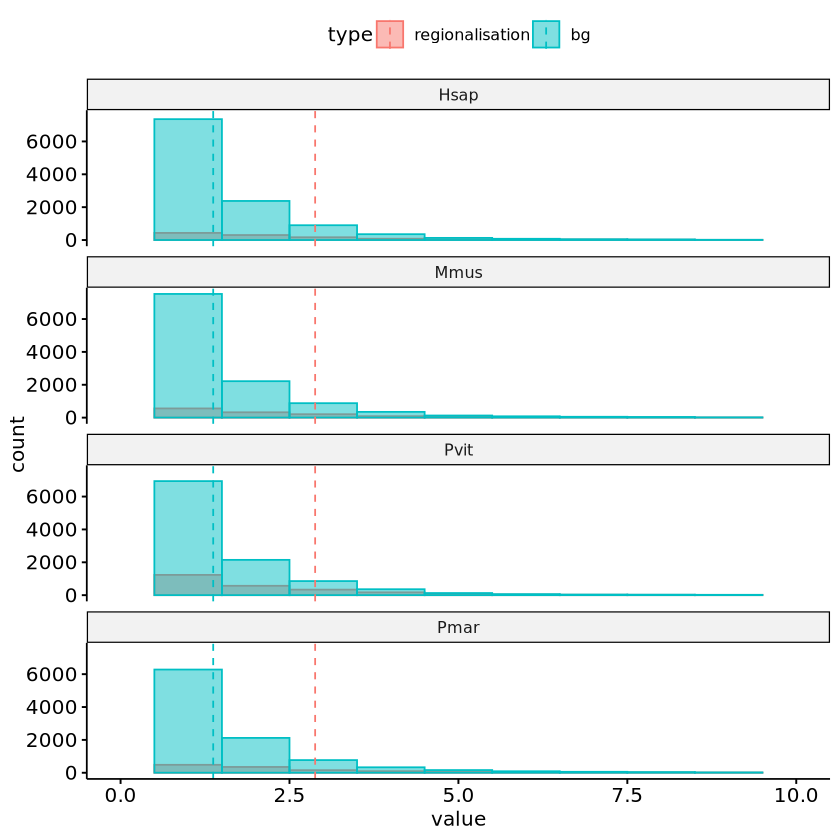

In [34]:
# showing the size of orthogroups (number of genes)
number_of_orthogroups <- reshape2::melt(number_genes)
number_of_orthogroups$type <- 'bg'

tmp1 <- number_of_orthogroups %>% filter(Orthogroup %in% Hsap_region_orthogroups & variable == 'Hsap')
tmp2 <- number_of_orthogroups %>% filter(Orthogroup %in% Mmus_region_orthogroups & variable == 'Mmus') 
tmp3 <- number_of_orthogroups %>% filter(Orthogroup %in% Pvit_region_orthogroups & variable == 'Pvit') 
tmp4 <- number_of_orthogroups %>% filter(Orthogroup %in% Pmar_region_orthogroups & variable == 'Pmar') 

tmp <- rbind(tmp1, tmp2, tmp3, tmp4)
tmp$type <- 'regionalisation'
number_of_orthogroups <- rbind(number_of_orthogroups, tmp)
number_of_orthogroups$species <- factor(number_of_orthogroups$variable, levels = species)
number_of_orthogroups$type <- factor(number_of_orthogroups$type, levels = c("regionalisation", "bg"))
#p <- gghistogram(number_of_orthogroups, x = "value", fill = "type", color = "type",
#    add = "mean",  binwidth = 1,  boundary = 0) +  facet_wrap(~species, ncol = 1) + xlim(0,10)
#p

In [23]:
t.test(number_genes[number_genes$Orthogroup %in% Mmus_region_orthogroups, "Mmus"],
            number_genes$Mmus)
wilcox.test(number_genes[number_genes$Orthogroup %in% Mmus_region_orthogroups, "Mmus"],
            number_genes$Mmus)


	Welch Two Sample t-test

data:  number_genes[number_genes$Orthogroup %in% Mmus_region_orthogroups, "Mmus"] and number_genes$Mmus
t = 9.4956, df = 1411, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 1.142704 1.737762
sample estimates:
mean of x mean of y 
 2.954785  1.514552 



	Wilcoxon rank sum test with continuity correction

data:  number_genes[number_genes$Orthogroup %in% Mmus_region_orthogroups, "Mmus"] and number_genes$Mmus
W = 13354856, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [25]:
t.test(number_genes[number_genes$Orthogroup %in% Hsap_region_orthogroups, "Hsap"],
            number_genes$Hsap)
wilcox.test(number_genes[number_genes$Orthogroup %in% Hsap_region_orthogroups, "Hsap"],
            number_genes$Hsap)


	Welch Two Sample t-test

data:  number_genes[number_genes$Orthogroup %in% Hsap_region_orthogroups, "Hsap"] and number_genes$Hsap
t = 12.936, df = 1213.1, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 1.683672 2.285690
sample estimates:
mean of x mean of y 
 3.394247  1.409566 



	Wilcoxon rank sum test with continuity correction

data:  number_genes[number_genes$Orthogroup %in% Hsap_region_orthogroups, "Hsap"] and number_genes$Hsap
W = 12338644, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [26]:
t.test(number_genes[number_genes$Orthogroup %in% Pvit_region_orthogroups, "Pvit"],
            number_genes$Pvit)
wilcox.test(number_genes[number_genes$Orthogroup %in% Pvit_region_orthogroups, "Pvit"],
            number_genes$Pvit)


	Welch Two Sample t-test

data:  number_genes[number_genes$Orthogroup %in% Pvit_region_orthogroups, "Pvit"] and number_genes$Pvit
t = 14.218, df = 2786.3, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 1.083212 1.429784
sample estimates:
mean of x mean of y 
 2.549296  1.292798 



	Wilcoxon rank sum test with continuity correction

data:  number_genes[number_genes$Orthogroup %in% Pvit_region_orthogroups, "Pvit"] and number_genes$Pvit
W = 25539590, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [27]:
t.test(number_genes[number_genes$Orthogroup %in% Pmar_region_orthogroups, "Pmar"],
            number_genes$Pmar)
wilcox.test(number_genes[number_genes$Orthogroup %in% Pmar_region_orthogroups, "Pmar"],
            number_genes$Pmar)


	Welch Two Sample t-test

data:  number_genes[number_genes$Orthogroup %in% Pmar_region_orthogroups, "Pmar"] and number_genes$Pmar
t = 11.961, df = 1296.9, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 1.439044 2.003691
sample estimates:
mean of x mean of y 
 2.988076  1.266709 



	Wilcoxon rank sum test with continuity correction

data:  number_genes[number_genes$Orthogroup %in% Pmar_region_orthogroups, "Pmar"] and number_genes$Pmar
W = 13433921, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [29]:
calc_OR <- function(set1, set2, universe_size) {
  overlap <- length(intersect(set1, set2))
  matrix_vals <- matrix(c(overlap, length(set1) - overlap, length(set2) - overlap, universe_size - length(set1) - length(set2) + overlap), 
                        nrow = 2)
    return(fisher.test(matrix_vals)$estimate)
}

In [30]:
# test whether these genes are significantly associated with WGD or SSD
WGD_SSD <- readRDS('../../../../10.dNdS/Combined.SSD_WGD.pairs.rds')

# only OR > 1 results were retained in calc_pvalue function
species <- c('Hsap', 'Mmus', 'Pvit', 'Pmar')
type <- c('WGD', 'SSD')

OR_WGD_SSD_region <- c()
for (s in species){
    tmp1 <- get(paste0(s, '_genes_in_region_orthogroups'))
    for (t in type){
        tmp2 <- WGD_SSD[[s]] %>% filter(type == t)
        tmp2 <- unique(c(tmp2$Dup1, tmp2$Dup2))
        tmp3 <- length(get(paste0(s, '_bg')))
        OR_WGD_SSD_region <- rbind(OR_WGD_SSD_region, c(s, t,  length(intersect(tmp1, tmp2)),
                                                        calc_OR(tmp1, tmp2, tmp3),
                                                        calc_pvalue(tmp1, tmp2, tmp3) ))
    }
}
OR_WGD_SSD_region <- as.data.frame(OR_WGD_SSD_region)
colnames(OR_WGD_SSD_region) <- c('species', 'type', 'number','ORs','pvalue')
OR_WGD_SSD_region$species <- factor(OR_WGD_SSD_region$species, levels = species)
OR_WGD_SSD_region$log_p_values <- -log10(as.double(OR_WGD_SSD_region$pvalue))
OR_WGD_SSD_region[is.infinite(OR_WGD_SSD_region$log_p_values), 'log_p_values'] = 200
OR_WGD_SSD_region$text <- paste(OR_WGD_SSD_region$number,  round(as.double(OR_WGD_SSD_region$ORs),2), sep = '_')
p <- ggplot(OR_WGD_SSD_region, aes(species, type, fill = log_p_values)) + 
        geom_tile(color = "white") + 
        scale_fill_gradient(low = "grey", high = "red", na.value = "white", 
                            name = expression(-log[10](P)), limits = c(0, 15), oob = scales::squish) +
        geom_text(aes(label = text), color = "black") + theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
        labs(x = "", y = "", title = "Fishers between oh/SSDpa to regionalisation genes")
ggsave(p, filename = paste0('figures/Vertebrate.WGD_SSD_comparison_mat_across_species_regionalisation_genes.pdf'), width = 6, height = 3)